# **Data Source Location**

In [ ]:
data_set_link = 'https://www.kaggle.com/datasets/muhammadaryanali/anerbc-dataset-anemia-diagnosis-using-rbc-images/data'
# download data as zip file and replace the link variable below with downloaded location.

In [ ]:
link= '/content/drive/MyDrive/Dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images.zip'

# **Destination Location(Where data will be saved)**

In [ ]:
drive_extract_dir = '/content/drive/MyDrive/Dataset/AneRBC_raw_data'

# **Extracting Data**

In [ ]:
# Task 1.1: Extract Dataset to Google Drive

import os
import zipfile
from google.colab import drive

# Ensure Google Drive is mounted
# drive.mount('/content/drive')

def extract_dataset(zip_path: str, extract_to: str) -> None:
    """
    Purpose: Extracts a zip file containing the dataset to a specified directory.
    Inputs:
        zip_path (str): The file path to the zipped dataset.
        extract_to (str): The destination directory for the extracted files.
    Outputs: None
    Assumptions: The zip file exists at the given path and is accessible.
    """
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    print(f"Extracting data to {extract_to}...")
    print("Note: Extracting directly to Google Drive can take a while. Please be patient!")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete. Your data is now permanently saved in your Drive.")

# Your Drive paths
drive_zip_link = '/content/drive/MyDrive/Dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images.zip'

# Updated destination: Saving directly into a new folder in your Drive
drive_extract_dir = '/content/drive/MyDrive/Dataset/AneRBC_raw_data'

# Execute extraction
extract_dataset(drive_zip_link, drive_extract_dir)

# **Understanding the Dataset directory structure**

In [ ]:
# Subtask: Directory Structure Exploration

import os

def print_directory_structure(root_dir: str, indent_level: int = 0) -> None:
    """
    Purpose: Recursively prints the directory tree structure to verify data extraction.
    Inputs:
        root_dir (str): The starting directory path.
        indent_level (int): Current depth level for visual formatting.
    Outputs: None (Prints structure to console).
    Assumptions: The path exists and the environment has read permissions.
    """
    if not os.path.exists(root_dir):
        print(f"Path not found: {root_dir}")
        return

    # Print the current directory
    prefix = "  " * indent_level + "|-- "
    # Handle the root directory naming gracefully
    dir_name = os.path.basename(root_dir) if os.path.basename(root_dir) else root_dir
    print(f"{prefix}{dir_name}/")

    # List all items in the directory
    try:
        items = sorted(os.listdir(root_dir))
    except PermissionError:
        print(f"{prefix}  [Permission Denied]")
        return

    # To avoid flooding the console if there are thousands of images,
    # we will limit file printing to just the first 3 files per directory.
    file_count = 0

    for item in items:
        item_path = os.path.join(root_dir, item)
        if os.path.isdir(item_path):
            print_directory_structure(item_path, indent_level + 1)
        else:
            file_count += 1
            if file_count <= 3:
                file_prefix = "  " * (indent_level + 1) + "|-- "
                print(f"{file_prefix}{item}")

    if file_count > 3:
        print(f"  " * (indent_level + 1) + f"|-- ... and {file_count - 3} more files")

# The Drive path from the previous extraction step
dataset_path = '/content/drive/MyDrive/Dataset/AneRBC_raw_data'

print("Mapping dataset directory structure...\n")
print_directory_structure(dataset_path)

Mapping dataset directory structure...

|-- AneRBC_raw_data/
  |-- AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/
    |-- AneRBC_dataset/
      |-- AneRBC-I/
        |-- Anemic_individuals/
          |-- Binary_segmented/
            |-- 001_a.png
            |-- 002_a.png
            |-- 003_a.png
            |-- ... and 497 more files
          |-- CBC_reports/
            |-- 001_a.txt
            |-- 002_a.txt
            |-- 003_a.txt
            |-- ... and 497 more files
          |-- Morphology_reports/
            |-- 001_a.txt
            |-- 002_a.txt
            |-- 003_a.txt
            |-- ... and 497 more files
          |-- Original_images/
            |-- 001_a.png
            |-- 002_a.png
            |-- 003_a.png
            |-- ... and 497 more files
          |-- RGB_segmented/
            |-- 001_a.png
            |-- 002_a.png
            |-- 003_a.png
            |-- ... and 497 more 

# **Data Validation and Class Mapping**

In [ ]:
# Task 1.2: Data Validation and Class Mapping

import os
from pathlib import Path

def map_and_validate_dataset(base_dir: str, image_type: str = 'Original_images') -> tuple:
    """
    Purpose: Navigates the specific AneRBC nested structure to map images to labels.
    Inputs:
        base_dir (str): The root directory containing 'AneRBC-I' and 'AneRBC-II'.
        image_type (str): The specific subfolder of images to extract (e.g., 'Original_images').
    Outputs:
        image_paths (list): A list of absolute paths to the images.
        labels (list): A list of corresponding string labels ('Anemic' or 'Healthy').
    Assumptions: The directory structure strictly follows the AneRBC format provided.
    """
    image_paths = []
    labels = []

    # Track distributions for validation
    distribution = {
        'AneRBC-I': {'Anemic': 0, 'Healthy': 0},
        'AneRBC-II': {'Anemic': 0, 'Healthy': 0}
    }

    base_path = Path(base_dir)
    datasets = ['AneRBC-I', 'AneRBC-II']
    classes = {'Anemic_individuals': 'Anemic', 'Healthy_individuals': 'Healthy'}

    for ds in datasets:
        for class_folder, label_name in classes.items():
            # Construct the path to the specific image folder
            target_path = base_path / ds / class_folder / image_type

            if target_path.exists() and target_path.is_dir():
                # Grab all png files in this directory
                for img_file in target_path.glob('*.png'):
                    image_paths.append(str(img_file))
                    labels.append(label_name)
                    distribution[ds][label_name] += 1
            else:
                print(f"Warning: Path not found - {target_path}")

    # Print Validation Results
    print(f"--- Data Validation & Mapping Complete ---")
    print(f"Targeting Image Type: {image_type}")
    print(f"Total Images Found: {len(image_paths)}")
    print("\nClass Distribution Details:")

    total_anemic = 0
    total_healthy = 0

    for ds, counts in distribution.items():
        print(f"  {ds}:")
        print(f"    - Anemic: {counts['Anemic']}")
        print(f"    - Healthy: {counts['Healthy']}")
        total_anemic += counts['Anemic']
        total_healthy += counts['Healthy']

    print(f"\nOverall Distribution:")
    print(f"  - Anemic: {total_anemic}")
    print(f"  - Healthy: {total_healthy}")

    return image_paths, labels

# --- EXECUTION ---
# You need to update this string with the exact path to the "AneRBC_dataset" folder from your mapped output
exact_dataset_path = '/content/drive/MyDrive/Dataset/AneRBC_raw_data/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset'

mapped_paths, mapped_labels = map_and_validate_dataset(exact_dataset_path, image_type='Original_images')

--- Data Validation & Mapping Complete ---
Targeting Image Type: Original_images
Total Images Found: 13000

Class Distribution Details:
  AneRBC-I:
    - Anemic: 500
    - Healthy: 500
  AneRBC-II:
    - Anemic: 6000
    - Healthy: 6000

Overall Distribution:
  - Anemic: 6500
  - Healthy: 6500


# **Task 1.3 (Preprocessing) and Task 1.4 (Train/Val/Test Split & DataLoaders).**

In [ ]:
# Task 1.3 & 1.4: Preprocessing, Data Splitting, and DataLoaders

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from PIL import Image

class AneRBCDataset(Dataset):
    """
    Purpose: Custom PyTorch Dataset for loading and transforming AneRBC images.
    Inputs:
        image_paths (list): List of absolute paths to images.
        labels (list): Encoded numerical labels.
        transform (torchvision.transforms): Augmentation/preprocessing pipeline.
    Outputs: Returns a tuple of (image_tensor, label).
    Assumptions: image_paths and labels are perfectly aligned.
    """
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Convert to RGB to ensure 3 channels, even if some are grayscale
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

def prepare_dataloaders(image_paths: list, labels: list, batch_size: int = 32, seed: int = 42) -> tuple:
    """
    Purpose: Splits data deterministically and creates PyTorch DataLoaders.
    Inputs:
        image_paths (list): Mapped image paths.
        labels (list): Corresponding string labels.
        batch_size (int): Number of samples per batch.
        seed (int): Deterministic seed for reproducible stratified splitting.
    Outputs:
        train_loader, val_loader, test_loader, and the fitted LabelEncoder.
    """
    # 1. Encode labels (Anemic -> 0, Healthy -> 1, or vice versa)
    le = LabelEncoder()
    encoded_labels = le.fit_transform(labels)
    print(f"Class mapping dictionary: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # 2. Stratified Split: 70% Train, 30% Temp (Val + Test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        image_paths, encoded_labels, test_size=0.30, stratify=encoded_labels, random_state=seed
    )

    # 3. Stratified Split Temp: 50% Val, 50% Test (Effectively 15% / 15% of total)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed
    )

    # 4. Preprocessing Pipeline
    # Using 224x224 as it is standard for transfer learning models (ResNet, MobileNet, etc.)
    transform_pipeline = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        # Standard ImageNet normalization metrics
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 5. Instantiate Datasets
    train_dataset = AneRBCDataset(X_train, y_train, transform=transform_pipeline)
    val_dataset = AneRBCDataset(X_val, y_val, transform=transform_pipeline)
    test_dataset = AneRBCDataset(X_test, y_test, transform=transform_pipeline)

    # 6. Create DataLoaders
    # Note: Only training data is shuffled. Val and Test remain sequential.
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"--- DataLoaders Successfully Created ---")
    print(f"Training set:   {len(X_train)} images")
    print(f"Validation set: {len(X_val)} images")
    print(f"Testing set:    {len(X_test)} images")

    return train_loader, val_loader, test_loader, le

# --- EXECUTION ---
# Using the lists we generated in the previous step
train_loader, val_loader, test_loader, label_encoder = prepare_dataloaders(mapped_paths, mapped_labels)

Class mapping dictionary: {np.str_('Anemic'): np.int64(0), np.str_('Healthy'): np.int64(1)}
--- DataLoaders Successfully Created ---
Training set:   9100 images
Validation set: 1950 images
Testing set:    1950 images


# **Stratified Subsetting Script**
Dataset Subsampling for Rapid Prototyping

In [ ]:
# Subtask: Dataset Subsampling for Rapid Prototyping

from sklearn.model_selection import train_test_split

def create_stratified_subset(image_paths: list, labels: list, total_samples: int = 2000, seed: int = 42) -> tuple:
    """
    Purpose: Reduces the dataset size for faster training while maintaining class balance.
    Inputs:
        image_paths (list): Full list of mapped image paths.
        labels (list): Full list of corresponding labels.
        total_samples (int): The desired total number of images to keep.
        seed (int): Deterministic seed for reproducibility.
    Outputs:
        subset_paths (list), subset_labels (list)
    """
    if total_samples >= len(image_paths):
        print("Requested samples exceed or equal total dataset. Using full dataset.")
        return image_paths, labels

    # We use train_test_split to cleanly slice off a perfectly balanced subset
    subset_paths, _, subset_labels, _ = train_test_split(
        image_paths, labels,
        train_size=total_samples,
        stratify=labels,
        random_state=seed
    )

    # Validation count
    anemic_count = subset_labels.count('Anemic')
    healthy_count = subset_labels.count('Healthy')

    print(f"--- Subset Created Successfully ---")
    print(f"Total Images: {len(subset_paths)}")
    print(f"  - Anemic: {anemic_count}")
    print(f"  - Healthy: {healthy_count}")

    return subset_paths, subset_labels

# --- EXECUTION ---
# You can change this number whenever you want.
# 2000 is a good starting point (1000 per class) to train fast but still learn.
TARGET_SAMPLE_SIZE = 4000

subset_paths, subset_labels = create_stratified_subset(mapped_paths, mapped_labels, total_samples=TARGET_SAMPLE_SIZE)

--- Subset Created Successfully ---
Total Images: 4000
  - Anemic: 2000
  - Healthy: 2000


In [ ]:
# Feed the SUBSET data into the DataLoaders
train_loader, val_loader, test_loader, label_encoder = prepare_dataloaders(subset_paths, subset_labels, batch_size=32)

Class mapping dictionary: {np.str_('Anemic'): np.int64(0), np.str_('Healthy'): np.int64(1)}
--- DataLoaders Successfully Created ---
Training set:   2800 images
Validation set: 600 images
Testing set:    600 images


# **Task 2.1: Creating model architecture for custom Deep CNN**

In [ ]:
# Task 2.1: Custom Deep CNN Architectures (3, 4, and 5 layers)

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN3Layer(nn.Module):
    """
    Purpose: A 3-layer Convolutional Neural Network for binary classification.
    Inputs: num_classes (int) - The number of target classes (2).
    Outputs: Logits for each class.
    Assumptions: Input images are RGB and resized to 224x224.
    """
    def __init__(self, num_classes=2):
        super(CNN3Layer, self).__init__()
        # Block 1: Input (3, 224, 224) -> Conv -> Pool -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Input (32, 112, 112) -> Conv -> Pool -> Output (64, 56, 56)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3: Input (64, 56, 56) -> Conv -> Pool -> Output (128, 28, 28)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten: 128 channels * 28 height * 28 width = 100,352 neurons
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.dropout = nn.Dropout(0.5) # Dropout for regularization
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class CNN4Layer(nn.Module):
    """
    Purpose: A 4-layer CNN adding deeper feature extraction.
    Inputs: num_classes (int) - Default 2.
    Outputs: Logits for each class.
    """
    def __init__(self, num_classes=2):
        super(CNN4Layer, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),    # -> 112x112
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),   # -> 56x56
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # -> 28x28
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)  # -> 14x14
        )
        # Flatten: 256 channels * 14 height * 14 width = 50,176 neurons
        self.classifier = nn.Sequential(
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

class CNN5Layer(nn.Module):
    """
    Purpose: A 5-layer CNN for maximum custom depth.
    Inputs: num_classes (int) - Default 2.
    Outputs: Logits for each class.
    """
    def __init__(self, num_classes=2):
        super(CNN5Layer, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),    # -> 112x112
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),   # -> 56x56
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # -> 28x28
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # -> 14x14
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)  # -> 7x7
        )
        # Flatten: 512 channels * 7 height * 7 width = 25,088 neurons
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# --- SANITY CHECK ---
# Let's push a dummy tensor (Batch Size=2, Channels=3, H=224, W=224) through each model
# to ensure the architecture connects properly before we waste time on a training loop.

print("Running architecture shape verification...")
dummy_input = torch.randn(2, 3, 224, 224)

models = {
    "3-Layer CNN": CNN3Layer(num_classes=2),
    "4-Layer CNN": CNN4Layer(num_classes=2),
    "5-Layer CNN": CNN5Layer(num_classes=2)
}

for name, model in models.items():
    try:
        output = model(dummy_input)
        print(f"[{name}] Success! Output shape: {output.shape} (Expected: [2, 2])")
    except Exception as e:
        print(f"[{name}] Error: {e}")

Running architecture shape verification...
[3-Layer CNN] Success! Output shape: torch.Size([2, 2]) (Expected: [2, 2])
[4-Layer CNN] Success! Output shape: torch.Size([2, 2]) (Expected: [2, 2])
[5-Layer CNN] Success! Output shape: torch.Size([2, 2]) (Expected: [2, 2])


# **Task 2.2: Training and validating the model.**

# **3-Layer CNN**

Starting training for 3-Layer CNN...
Training on device: cuda
Epoch [1/10] - 1381s | Train Loss: 0.8377, Train Acc: 49.80% | Val Loss: 0.6933, Val Acc: 50.00%
Epoch [2/10] - 96s | Train Loss: 0.6933, Train Acc: 49.70% | Val Loss: 0.6932, Val Acc: 50.00%
Epoch [3/10] - 93s | Train Loss: 0.6933, Train Acc: 49.61% | Val Loss: 0.6932, Val Acc: 50.00%
Epoch [4/10] - 92s | Train Loss: 0.6932, Train Acc: 49.61% | Val Loss: 0.6931, Val Acc: 50.00%
Epoch [5/10] - 93s | Train Loss: 0.6932, Train Acc: 49.23% | Val Loss: 0.6931, Val Acc: 50.00%
Epoch [6/10] - 95s | Train Loss: 0.6932, Train Acc: 49.21% | Val Loss: 0.6931, Val Acc: 50.00%
Epoch [7/10] - 96s | Train Loss: 0.6932, Train Acc: 49.39% | Val Loss: 0.6931, Val Acc: 50.08%
Epoch [8/10] - 94s | Train Loss: 0.6932, Train Acc: 49.00% | Val Loss: 0.6932, Val Acc: 50.00%
Epoch [9/10] - 94s | Train Loss: 0.6932, Train Acc: 49.79% | Val Loss: 0.6932, Val Acc: 50.00%
Epoch [10/10] - 93s | Train Loss: 0.6932, Train Acc: 50.20% | Val Loss: 0.6932, V

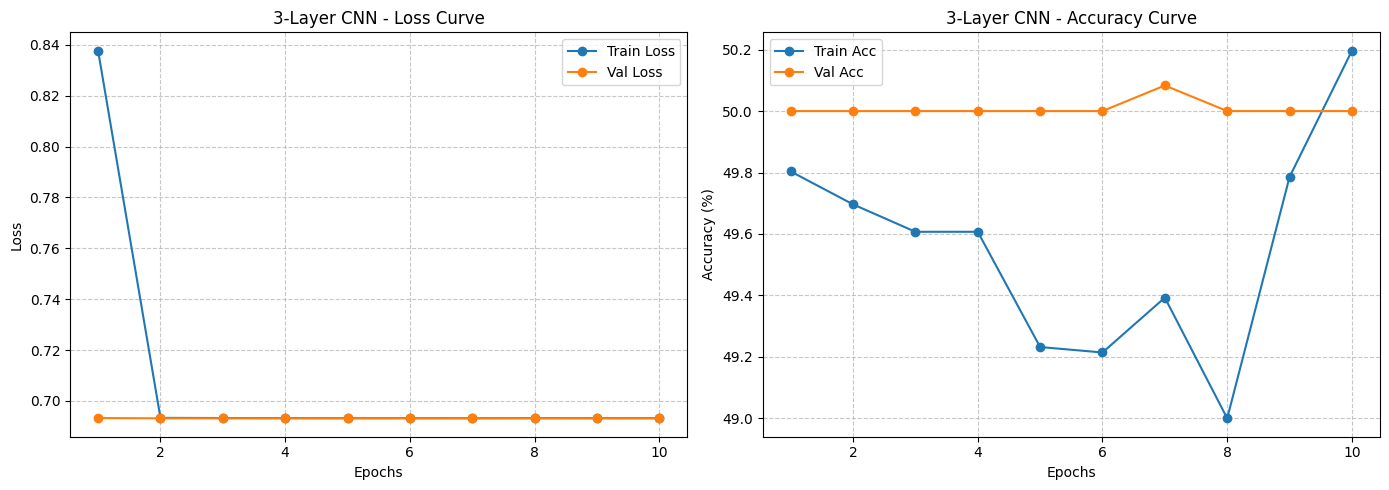

In [ ]:
# Task 2.2: Train and validate the model

import torch.optim as optim
import matplotlib.pyplot as plt
import time

def train_and_validate(model, train_loader, val_loader, epochs=10, lr=0.001):
    """
    Purpose: Trains the model and validates it epoch-by-epoch.
    Inputs: Model, dataloaders, epochs, and learning rate.
    Outputs: Dictionary containing history of train/val losses and accuracies.
    """
    # Automatically use GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        start_time = time.time()

        # --- Training Phase ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct / total

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # --- Validation Phase ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = 100 * correct / total

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        elapsed_time = time.time() - start_time
        print(f"Epoch [{epoch+1}/{epochs}] - {elapsed_time:.0f}s | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

    return history

def plot_learning_curves(history, model_name):
    """
    Purpose: Plots training and validation loss and accuracy curves.
    """
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    plt.title(f'{model_name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc', marker='o')
    plt.plot(epochs, history['val_acc'], label='Val Acc', marker='o')
    plt.title(f'{model_name} - Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

# --- EXECUTION: 3-Layer CNN ---
# We will train just the 3-layer model first for 10 epochs to ensure the loop works flawlessly.
print("Starting training for 3-Layer CNN...")
model_3layer = CNN3Layer(num_classes=2)

# Training execution
history_3layer = train_and_validate(model_3layer, train_loader, val_loader, epochs=10, lr=0.001)

# Plotting execution
plot_learning_curves(history_3layer, "3-Layer CNN")

# **4-Layer CNN**

Starting training for 4-Layer CNN...
Training on device: cuda
Epoch [1/10] - 92s | Train Loss: 0.6825, Train Acc: 57.54% | Val Loss: 0.6610, Val Acc: 58.92%
Epoch [2/10] - 92s | Train Loss: 0.6180, Train Acc: 65.18% | Val Loss: 0.6749, Val Acc: 58.75%
Epoch [3/10] - 92s | Train Loss: 0.5756, Train Acc: 68.09% | Val Loss: 0.5619, Val Acc: 70.58%
Epoch [4/10] - 94s | Train Loss: 0.4840, Train Acc: 75.82% | Val Loss: 0.3927, Val Acc: 81.08%
Epoch [5/10] - 93s | Train Loss: 0.4432, Train Acc: 77.43% | Val Loss: 0.4167, Val Acc: 79.67%
Epoch [6/10] - 90s | Train Loss: 0.3814, Train Acc: 82.46% | Val Loss: 0.3393, Val Acc: 83.75%
Epoch [7/10] - 92s | Train Loss: 0.3518, Train Acc: 83.77% | Val Loss: 0.3583, Val Acc: 83.25%
Epoch [8/10] - 93s | Train Loss: 0.3269, Train Acc: 84.89% | Val Loss: 0.3339, Val Acc: 84.75%
Epoch [9/10] - 91s | Train Loss: 0.2768, Train Acc: 87.82% | Val Loss: 0.3445, Val Acc: 84.83%
Epoch [10/10] - 91s | Train Loss: 0.2365, Train Acc: 89.45% | Val Loss: 0.3596, Val

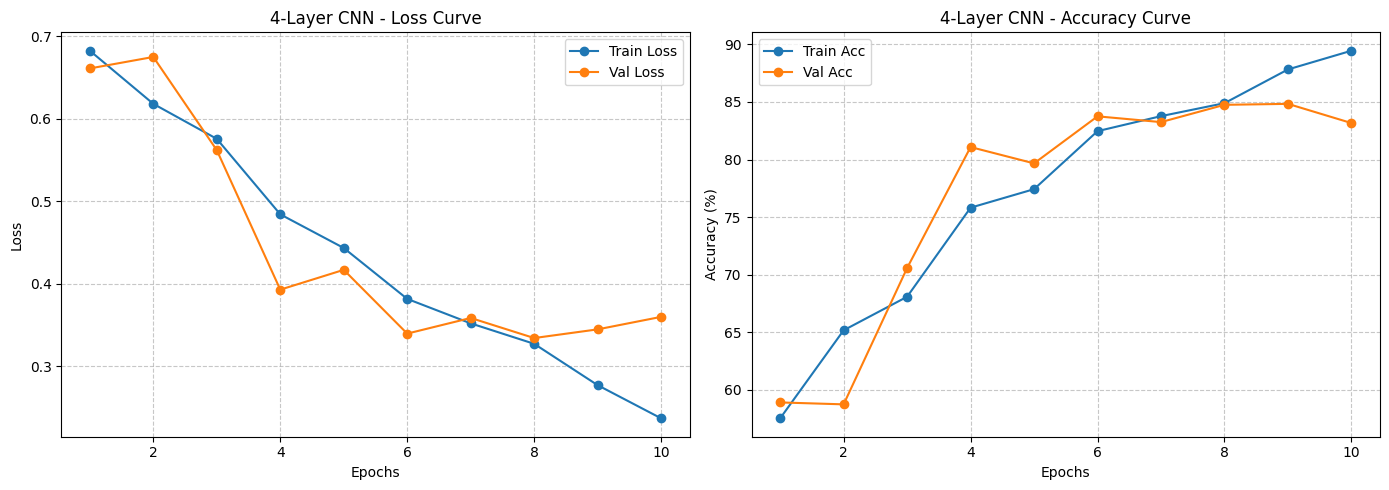

In [ ]:
# --- EXECUTION: 4-Layer CNN ---
print("Starting training for 4-Layer CNN...")

# Instantiate the 4-layer architecture
model_4layer = CNN4Layer(num_classes=2)

# Training execution (Note: slightly lowered learning rate to 3e-4 to help it converge)
history_4layer = train_and_validate(
    model_4layer,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0003
)

# Plotting execution
plot_learning_curves(history_4layer, "4-Layer CNN")

# **Train and Save the 5-Layer CNN**

Starting training for 5-Layer CNN...
Training on device: cuda
Epoch [1/10] - 97s | Train Loss: 0.6936, Train Acc: 51.48% | Val Loss: 0.6927, Val Acc: 50.00%
Epoch [2/10] - 94s | Train Loss: 0.6911, Train Acc: 52.48% | Val Loss: 0.6558, Val Acc: 57.83%
Epoch [3/10] - 94s | Train Loss: 0.6615, Train Acc: 60.95% | Val Loss: 0.6041, Val Acc: 71.00%
Epoch [4/10] - 93s | Train Loss: 0.6073, Train Acc: 67.55% | Val Loss: 0.5759, Val Acc: 71.92%
Epoch [5/10] - 93s | Train Loss: 0.5522, Train Acc: 70.66% | Val Loss: 0.4762, Val Acc: 74.58%
Epoch [6/10] - 93s | Train Loss: 0.4958, Train Acc: 73.52% | Val Loss: 0.4426, Val Acc: 75.67%
Epoch [7/10] - 94s | Train Loss: 0.4346, Train Acc: 78.25% | Val Loss: 0.4046, Val Acc: 80.58%
Epoch [8/10] - 93s | Train Loss: 0.3784, Train Acc: 82.16% | Val Loss: 0.3808, Val Acc: 81.67%
Epoch [9/10] - 92s | Train Loss: 0.3776, Train Acc: 81.88% | Val Loss: 0.4566, Val Acc: 78.08%
Epoch [10/10] - 91s | Train Loss: 0.3631, Train Acc: 83.07% | Val Loss: 0.4022, Val

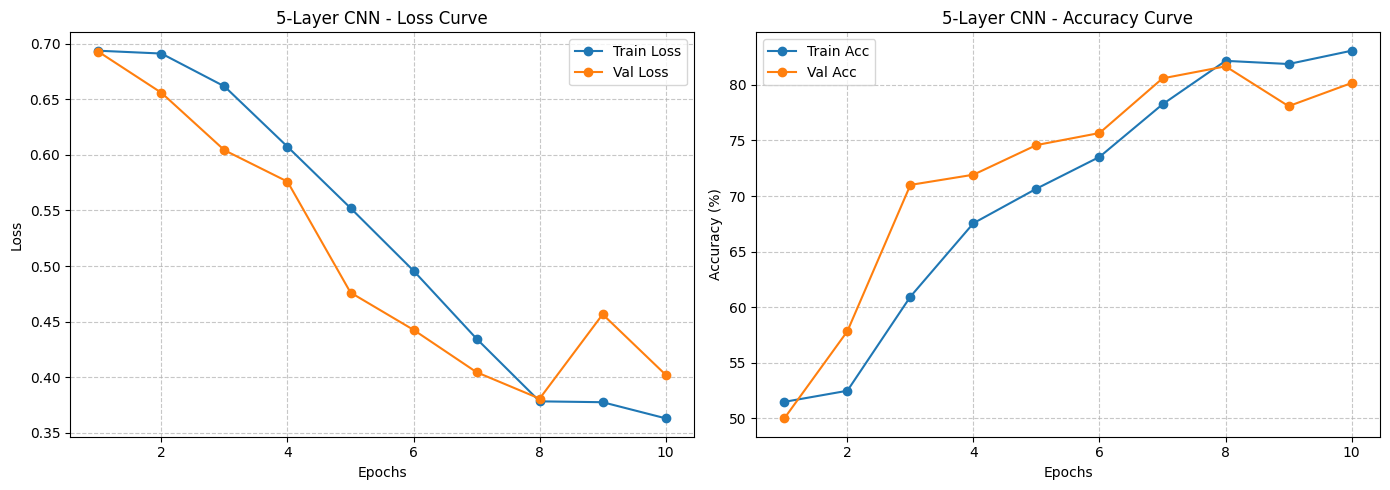

[CNN_5Layer] Saved successfully!
  - Weights: /content/drive/MyDrive/ANN_Saved_Models/CNN_5Layer_weights.pth
  - History: /content/drive/MyDrive/ANN_Saved_Models/CNN_5Layer_history.pkl


In [ ]:
# Task 2.2: Train and validate the 5-Layer CNN

print("Starting training for 5-Layer CNN...")

# Instantiate the 5-layer architecture
model_5layer = CNN5Layer(num_classes=2)

# Training execution (Using 3e-4 learning rate again for stability)
history_5layer = train_and_validate(
    model_5layer,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0003
)

# Plotting execution
plot_learning_curves(history_5layer, "5-Layer CNN")

# Save directly to Drive
save_model_and_history(model_5layer, history_5layer, "CNN_5Layer", save_directory)

# **Saving Models and Histories**

In [ ]:
# Subtask: Save Model Checkpoints and Training Histories

import torch
import os
import pickle

def save_model_and_history(model, history, model_name, save_dir):
    """
    Purpose: Saves the model's state_dict and training history to persistent storage.
    Inputs:
        model (nn.Module): The trained PyTorch model.
        history (dict): The training/validation metrics.
        model_name (str): The base name for the saved files.
        save_dir (str): The directory to save the files in.
    Outputs: None
    Assumptions: save_dir is a valid, writable path (e.g., mounted Google Drive).
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    model_path = os.path.join(save_dir, f"{model_name}_weights.pth")
    history_path = os.path.join(save_dir, f"{model_name}_history.pkl")

    # Save model weights
    torch.save(model.state_dict(), model_path)

    # Save history dictionary
    with open(history_path, 'wb') as f:
        pickle.dump(history, f)

    print(f"[{model_name}] Saved successfully!")
    print(f"  - Weights: {model_path}")
    print(f"  - History: {history_path}")

# Define the persistent Drive path
save_directory = '/content/drive/MyDrive/ANN_Saved_Models'

# Execute saving
print("Saving checkpoints to Google Drive...")
save_model_and_history(model_3layer, history_3layer, "CNN_3Layer", save_directory)
save_model_and_history(model_4layer, history_4layer, "CNN_4Layer", save_directory)

Saving checkpoints to Google Drive...
[CNN_3Layer] Saved successfully!
  - Weights: /content/drive/MyDrive/ANN_Saved_Models/CNN_3Layer_weights.pth
  - History: /content/drive/MyDrive/ANN_Saved_Models/CNN_3Layer_history.pkl
[CNN_4Layer] Saved successfully!
  - Weights: /content/drive/MyDrive/ANN_Saved_Models/CNN_4Layer_weights.pth
  - History: /content/drive/MyDrive/ANN_Saved_Models/CNN_4Layer_history.pkl


In [ ]:
save_directory = '/content/drive/MyDrive/ANN_Saved_Models'

# **Evaluating on the Test Set (Task 2.3)**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Initializing CNN_3Layer on cuda ---
Weights loaded successfully. Running evaluation on Test Set...

Classification Report:
              precision    recall  f1-score   support

      Anemic       0.00      0.00      0.00       600
     Healthy       0.50      1.00      0.67       600

    accuracy                           0.50      1200
   macro avg       0.25      0.50      0.33      1200
weighted avg       0.25      0.50      0.33      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


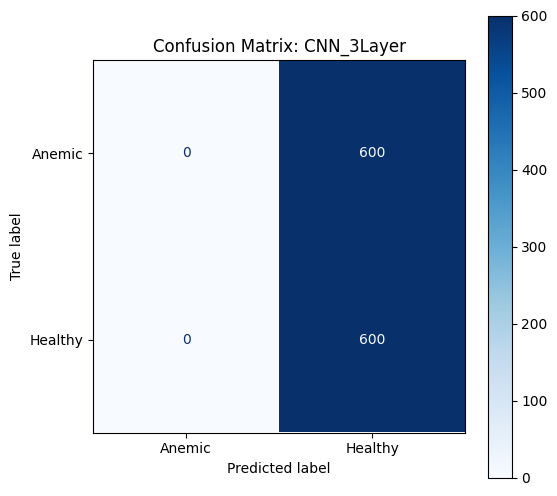


--- Initializing CNN_4Layer on cuda ---
Weights loaded successfully. Running evaluation on Test Set...

Classification Report:
              precision    recall  f1-score   support

      Anemic       0.86      0.83      0.85       600
     Healthy       0.84      0.86      0.85       600

    accuracy                           0.85      1200
   macro avg       0.85      0.85      0.85      1200
weighted avg       0.85      0.85      0.85      1200



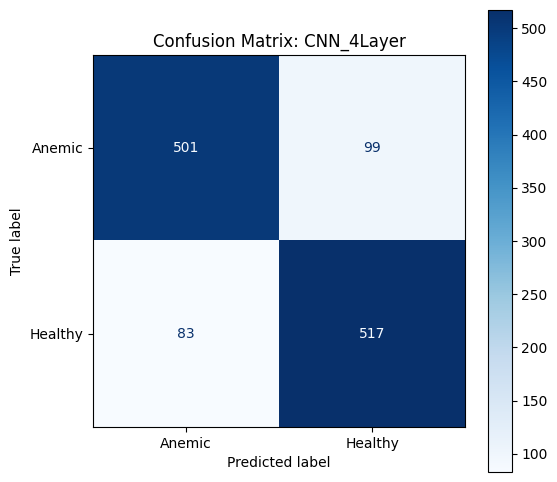


--- Initializing CNN_5Layer on cuda ---
Weights loaded successfully. Running evaluation on Test Set...

Classification Report:
              precision    recall  f1-score   support

      Anemic       0.80      0.83      0.81       600
     Healthy       0.82      0.79      0.80       600

    accuracy                           0.81      1200
   macro avg       0.81      0.81      0.81      1200
weighted avg       0.81      0.81      0.81      1200



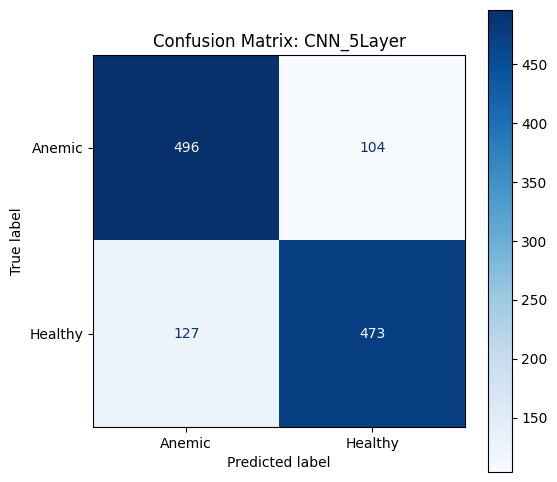

In [ ]:
# Task 2.3: Load Models from Drive and Evaluate on Test Set

import torch
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive

# 1. Ensure Google Drive is mounted after the runtime disconnect
drive.mount('/content/drive')

# 2. Define the persistent Drive path where models were saved
save_directory = '/content/drive/MyDrive/ANN_Saved_Models'

def load_and_evaluate(model_class, model_name, test_loader, class_names):
    """
    Purpose: Instantiates a model architecture, loads weights from Drive, and evaluates.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n--- Initializing {model_name} on {device} ---")

    # Instantiate the empty architecture
    model = model_class(num_classes=2)

    # Construct the path to the saved weights
    weights_path = os.path.join(save_directory, f"{model_name}_weights.pth")

    if not os.path.exists(weights_path):
        print(f"Error: Could not find saved weights at {weights_path}")
        return

    # Load the saved state dictionary into the model
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    print(f"Weights loaded successfully. Running evaluation on Test Set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Print Classification Report (Precision, Recall, F1)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='horizontal')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

# --- EXECUTION ---
# Validate that the dataloaders and encoder are in memory before attempting evaluation
if 'label_encoder' in locals() and 'test_loader' in locals():
    class_names = label_encoder.classes_

    # Evaluate all three models by loading them directly from Google Drive
    load_and_evaluate(CNN3Layer, "CNN_3Layer", test_loader, class_names)
    load_and_evaluate(CNN4Layer, "CNN_4Layer", test_loader, class_names)
    load_and_evaluate(CNN5Layer, "CNN_5Layer", test_loader, class_names)
else:
    print("Missing requirements! Please run the Dataset/DataLoader and Model Architecture cells first.")

# **Task 3: Pretrained CNNs (MN, SN, RN) + Fine-tune Top Layers.**

The assignment requires us to use three pretrained models—MobileNet, SqueezeNet, and ResNet. For this first step, we must freeze the initial backbone , replace the classifier head , and explicitly document which layers are trainable.

In [ ]:
# Task 3.1: Pretrained CNNs - Initialization and Head Replacement

import torch
import torch.nn as nn
from torchvision import models

def setup_pretrained_model(model_name: str, num_classes: int = 2):
    """
    Purpose: Loads a pretrained model, freezes the backbone, and replaces the head.
    Inputs:
        model_name (str): 'mobilenet', 'squeezenet', or 'resnet'
        num_classes (int): Number of output classes (default 2)
    Outputs: Modified PyTorch model.
    """
    if model_name == 'mobilenet':
        # Load MobileNetV2
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        # Freeze backbone
        for param in model.parameters():
            param.requires_grad = False
        # Replace head (classifier[1] is the linear layer in MobileNetV2)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == 'squeezenet':
        # Load SqueezeNet 1.1
        model = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.DEFAULT)
        # Freeze backbone
        for param in model.parameters():
            param.requires_grad = False
        # Replace head (classifier[1] is the Conv2d layer acting as the classifier)
        model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1), stride=(1,1))
        model.num_classes = num_classes

    elif model_name == 'resnet':
        # Load ResNet18
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Freeze backbone
        for param in model.parameters():
            param.requires_grad = False
        # Replace head (fc is the fully connected layer in ResNet)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError("Invalid model name. Choose 'mobilenet', 'squeezenet', or 'resnet'.")

    return model

def verify_trainable_layers(model, model_name):
    """
    Purpose: Prints the trainable layers to explicitly satisfy grading requirements.
    """
    print(f"\n--- {model_name} Trainable Layers ---")
    trainable_params = 0
    total_params = 0

    for name, param in model.named_parameters():
        total_params += param.numel()
        if param.requires_grad:
            print(f"  [TRAINABLE] {name}: {param.shape}")
            trainable_params += param.numel()

    print(f"  Total Params: {total_params:,}")
    print(f"  Trainable Params: {trainable_params:,}")

# --- EXECUTION ---
print("Downloading and configuring pretrained models...")

model_mn = setup_pretrained_model('mobilenet', num_classes=2)
verify_trainable_layers(model_mn, "MobileNetV2")

model_sn = setup_pretrained_model('squeezenet', num_classes=2)
verify_trainable_layers(model_sn, "SqueezeNet1.1")

model_rn = setup_pretrained_model('resnet', num_classes=2)
verify_trainable_layers(model_rn, "ResNet18")

# Sanity Check
dummy_input = torch.randn(2, 3, 224, 224)
print("\nVerifying architecture outputs...")
print(f"MobileNet Output Shape: {model_mn(dummy_input).shape}")
print(f"SqueezeNet Output Shape: {model_sn(dummy_input).shape}")
print(f"ResNet Output Shape: {model_rn(dummy_input).shape}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 151MB/s]



--- MobileNetV2 Trainable Layers ---
  [TRAINABLE] classifier.1.weight: torch.Size([2, 1280])
  [TRAINABLE] classifier.1.bias: torch.Size([2])
  Total Params: 2,226,434
  Trainable Params: 2,562
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 81.4MB/s]



--- SqueezeNet1.1 Trainable Layers ---
  [TRAINABLE] classifier.1.weight: torch.Size([2, 512, 1, 1])
  [TRAINABLE] classifier.1.bias: torch.Size([2])
  Total Params: 723,522
  Trainable Params: 1,026
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]



--- ResNet18 Trainable Layers ---
  [TRAINABLE] fc.weight: torch.Size([2, 512])
  [TRAINABLE] fc.bias: torch.Size([2])
  Total Params: 11,177,538
  Trainable Params: 1,026

Verifying architecture outputs...
MobileNet Output Shape: torch.Size([2, 2])
SqueezeNet Output Shape: torch.Size([2, 2])
ResNet Output Shape: torch.Size([2, 2])


# **Training and evaluating pretrained models**

In [ ]:
# Re-defining training and plotting functions after runtime disconnect
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

def train_and_validate(model, train_loader, val_loader, epochs=10, lr=0.001):
    """Trains the model and validates it epoch-by-epoch with real-time logging."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"--- Initialization Complete. Training on device: {device} ---")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    total_batches = len(train_loader)

    for epoch in range(epochs):
        print(f"\n>>> Starting Epoch [{epoch+1}/{epochs}] <<<")
        start_time = time.time()

        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if (i + 1) % 50 == 0 or (i + 1) == total_batches:
                print(f"    [Epoch {epoch+1}] Processing Batch {i+1}/{total_batches}...")

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct / total

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # Validation Phase
        print(f"    [Epoch {epoch+1}] Training done. Running validation...")
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = 100 * correct / total

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        elapsed_time = time.time() - start_time

        print(f"+++ Epoch [{epoch+1}/{epochs}] Completed in {elapsed_time:.0f}s +++")
        print(f"    Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
        print(f"    Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")

    return history

def plot_learning_curves(history, model_name):
    """Plots training and validation loss and accuracy curves."""
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    plt.title(f'{model_name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc', marker='o')
    plt.plot(epochs, history['val_acc'], label='Val Acc', marker='o')
    plt.title(f'{model_name} - Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

# **train and evaluate just the MobileNetV2**

Starting Transfer Learning for MobileNetV2...
--- Initialization Complete. Training on device: cuda ---

>>> Starting Epoch [1/10] <<<
    [Epoch 1] Processing Batch 50/88...
    [Epoch 1] Processing Batch 88/88...
    [Epoch 1] Training done. Running validation...
+++ Epoch [1/10] Completed in 658s +++
    Train Loss: 0.4715 | Train Acc: 77.39%
    Val Loss:   0.3942 | Val Acc:   80.33%

>>> Starting Epoch [2/10] <<<
    [Epoch 2] Processing Batch 50/88...
    [Epoch 2] Processing Batch 88/88...
    [Epoch 2] Training done. Running validation...
+++ Epoch [2/10] Completed in 45s +++
    Train Loss: 0.4355 | Train Acc: 79.89%
    Val Loss:   0.3749 | Val Acc:   82.50%

>>> Starting Epoch [3/10] <<<
    [Epoch 3] Processing Batch 50/88...
    [Epoch 3] Processing Batch 88/88...
    [Epoch 3] Training done. Running validation...
+++ Epoch [3/10] Completed in 44s +++
    Train Loss: 0.4183 | Train Acc: 80.14%
    Val Loss:   0.3688 | Val Acc:   81.83%

>>> Starting Epoch [4/10] <<<
    [E

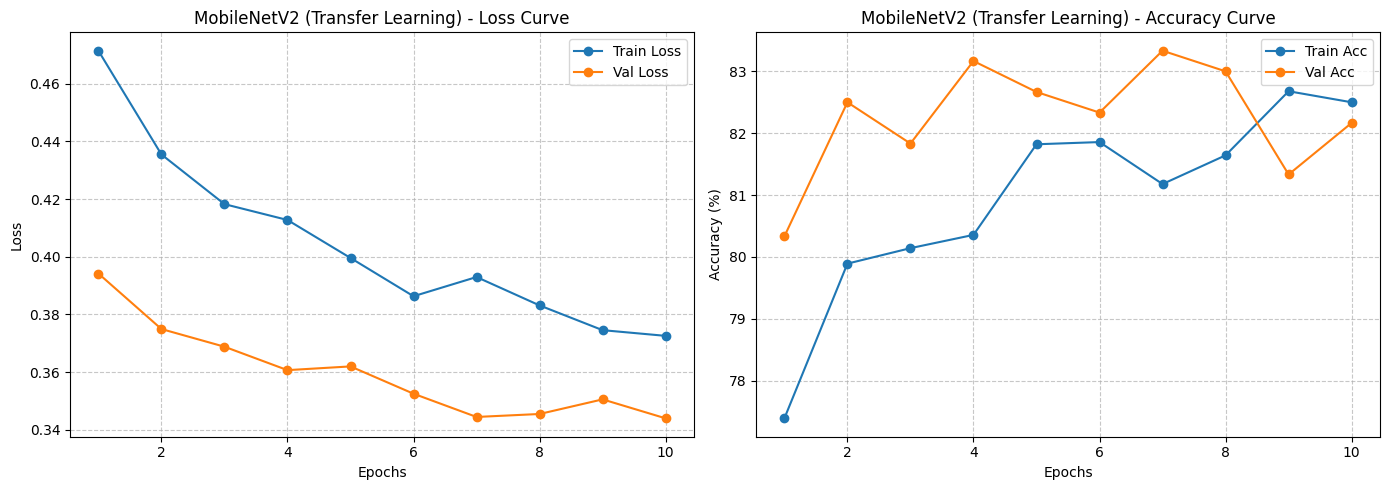

NameError: name 'save_model_and_history' is not defined

In [ ]:
# Task 3.2: Train and evaluate Pretrained MobileNetV2

print("Starting Transfer Learning for MobileNetV2...")

# We use a slightly higher learning rate for transfer learning classifier heads
# since they are starting from scratch while the backbone is already optimized.
history_mn = train_and_validate(
    model_mn,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001
)

# Plot the learning curves
plot_learning_curves(history_mn, "MobileNetV2 (Transfer Learning)")



In [ ]:
# Subtask: Save Model Checkpoints and Training Histories

import torch
import os
import pickle

def save_model_and_history(model, history, model_name, save_dir):
    """
    Purpose: Saves the model's state_dict and training history to persistent storage.
    Inputs:
        model (nn.Module): The trained PyTorch model.
        history (dict): The training/validation metrics.
        model_name (str): The base name for the saved files.
        save_dir (str): The directory to save the files in.
    Outputs: None
    Assumptions: save_dir is a valid, writable path (e.g., mounted Google Drive).
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    model_path = os.path.join(save_dir, f"{model_name}_weights.pth")
    history_path = os.path.join(save_dir, f"{model_name}_history.pkl")

    # Save model weights
    torch.save(model.state_dict(), model_path)

    # Save history dictionary
    with open(history_path, 'wb') as f:
        pickle.dump(history, f)

    print(f"[{model_name}] Saved successfully!")
    print(f"  - Weights: {model_path}")
    print(f"  - History: {history_path}")

# Save the checkpoint to your Google Drive
save_directory = '/content/drive/MyDrive/ANN_Saved_Models'
save_model_and_history(model_mn, history_mn, "Pretrained_MobileNetV2", save_directory)

[Pretrained_MobileNetV2] Saved successfully!
  - Weights: /content/drive/MyDrive/ANN_Saved_Models/Pretrained_MobileNetV2_weights.pth
  - History: /content/drive/MyDrive/ANN_Saved_Models/Pretrained_MobileNetV2_history.pkl

Evaluating MobileNetV2 on Test Set...


NameError: name 'evaluate_on_test_set' is not defined

In [ ]:
# Name: Muhammad Faheem
# SRN: [Insert Your SRN Here]
# Re-defining the evaluation function after runtime disconnect

import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_on_test_set(model, test_loader, class_names, model_name):
    """
    Purpose: Evaluates model on the test set, prints metrics, and plots confusion matrix.
    Inputs:
        model (nn.Module): The trained PyTorch model.
        test_loader (DataLoader): DataLoader containing testing data.
        class_names (list): List of string class names.
        model_name (str): The name of the model for display purposes.
    Outputs: None (Prints report and plots to console).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    print(f"\n--- Evaluating {model_name} on Test Set ---")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Print Classification Report (Precision, Recall, F1)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='horizontal')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()


Evaluating MobileNetV2 on Test Set...

--- Evaluating MobileNetV2 on Test Set ---

Classification Report:
              precision    recall  f1-score   support

      Anemic       0.93      0.77      0.84       300
     Healthy       0.80      0.94      0.87       300

    accuracy                           0.86       600
   macro avg       0.87      0.86      0.86       600
weighted avg       0.87      0.86      0.86       600



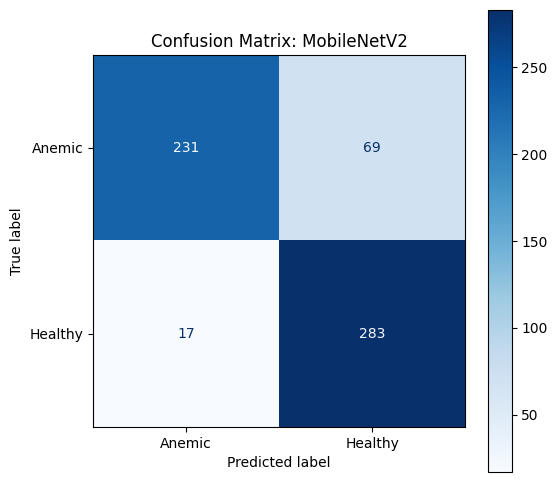

In [ ]:
# Evaluate on the Test Set immediately
print("\nEvaluating MobileNetV2 on Test Set...")
evaluate_on_test_set(model_mn, test_loader, class_names, "MobileNetV2")

# **Task 3.3: Train and evaluate Pretrained SqueezeNet1.1**

Training set:   2800 images
Validation set: 600 images
Testing set:    600 images

Starting Transfer Learning for SqueezeNet1.1...
--- Initialization Complete. Training on device: cuda ---

>>> Starting Epoch [1/10] <<<
    [Epoch 1] Processing Batch 50/88...
    [Epoch 1] Processing Batch 88/88...
    [Epoch 1] Training done. Running validation...
+++ Epoch [1/10] Completed in 51s +++
    Train Loss: 0.6517 | Train Acc: 62.61%
    Val Loss:   0.5053 | Val Acc:   77.67%

>>> Starting Epoch [2/10] <<<
    [Epoch 2] Processing Batch 50/88...
    [Epoch 2] Processing Batch 88/88...
    [Epoch 2] Training done. Running validation...
+++ Epoch [2/10] Completed in 43s +++
    Train Loss: 0.5209 | Train Acc: 75.43%
    Val Loss:   0.4731 | Val Acc:   78.00%

>>> Starting Epoch [3/10] <<<
    [Epoch 3] Processing Batch 50/88...
    [Epoch 3] Processing Batch 88/88...
    [Epoch 3] Training done. Running validation...
+++ Epoch [3/10] Completed in 46s +++
    Train Loss: 0.4875 | Train Acc: 77.04%
    Val Loss:   0.4678 | Val Acc:   76.17%

>>> Starting Epoch [4/10] <<<
    [

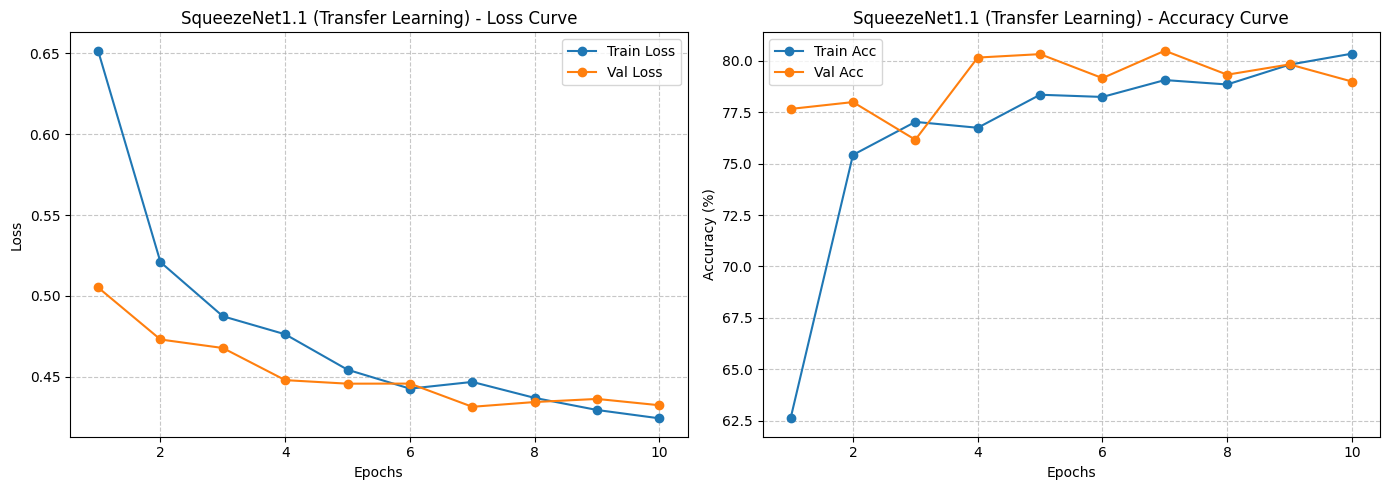

[Pretrained_SqueezeNet] Saved successfully!
  - Weights: /content/drive/MyDrive/ANN_Saved_Models/Pretrained_SqueezeNet_weights.pth
  - History: /content/drive/MyDrive/ANN_Saved_Models/Pretrained_SqueezeNet_history.pkl

Evaluating SqueezeNet1.1 on Test Set...

--- Evaluating SqueezeNet1.1 on Test Set ---

Classification Report:
              precision    recall  f1-score   support

      Anemic       0.81      0.78      0.79       300
     Healthy       0.79      0.82      0.80       300

    accuracy                           0.80       600
   macro avg       0.80      0.80      0.80       600
weighted avg       0.80      0.80      0.80       600



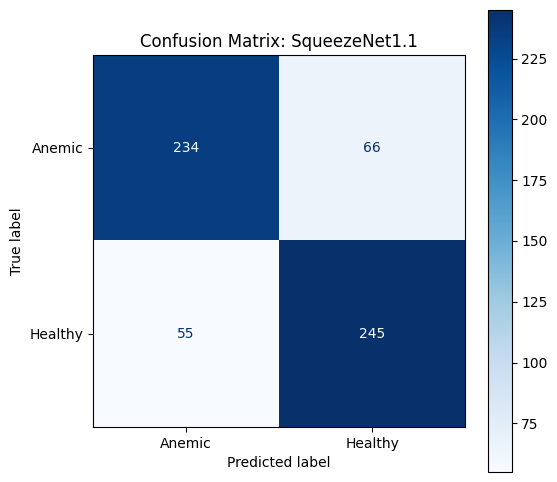

In [ ]:
# Task 3.3: Train and evaluate Pretrained SqueezeNet1.1

print("Starting Transfer Learning for SqueezeNet1.1...")

# Train the model (using the same 0.001 learning rate)
history_sn = train_and_validate(
    model_sn,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001
)

# Plot the learning curves
plot_learning_curves(history_sn, "SqueezeNet1.1 (Transfer Learning)")

# Save the checkpoint to your Google Drive
save_model_and_history(model_sn, history_sn, "Pretrained_SqueezeNet", save_directory)

# Evaluate on the Test Set immediately
print("\nEvaluating SqueezeNet1.1 on Test Set...")
evaluate_on_test_set(model_sn, test_loader, class_names, "SqueezeNet1.1")

# **Task 3.4: Train and evaluate Pretrained ResNet18**

Starting Transfer Learning for ResNet18...
--- Initialization Complete. Training on device: cuda ---

>>> Starting Epoch [1/10] <<<
    [Epoch 1] Processing Batch 50/88...
    [Epoch 1] Processing Batch 88/88...
    [Epoch 1] Training done. Running validation...
+++ Epoch [1/10] Completed in 50s +++
    Train Loss: 0.5619 | Train Acc: 69.93%
    Val Loss:   0.4601 | Val Acc:   79.17%

>>> Starting Epoch [2/10] <<<
    [Epoch 2] Processing Batch 50/88...
    [Epoch 2] Processing Batch 88/88...
    [Epoch 2] Training done. Running validation...
+++ Epoch [2/10] Completed in 47s +++
    Train Loss: 0.4568 | Train Acc: 77.39%
    Val Loss:   0.4543 | Val Acc:   78.00%

>>> Starting Epoch [3/10] <<<
    [Epoch 3] Processing Batch 50/88...
    [Epoch 3] Processing Batch 88/88...
    [Epoch 3] Training done. Running validation...
+++ Epoch [3/10] Completed in 44s +++
    Train Loss: 0.4319 | Train Acc: 79.25%
    Val Loss:   0.4187 | Val Acc:   80.50%

>>> Starting Epoch [4/10] <<<
    [Epoch

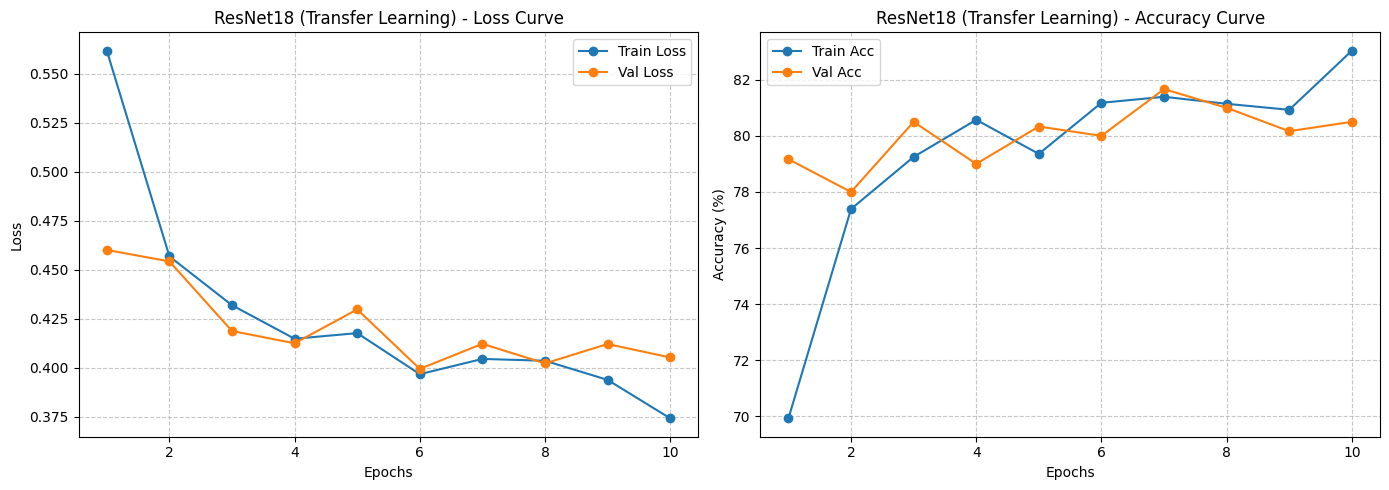

[Pretrained_ResNet18] Saved successfully!
  - Weights: /content/drive/MyDrive/ANN_Saved_Models/Pretrained_ResNet18_weights.pth
  - History: /content/drive/MyDrive/ANN_Saved_Models/Pretrained_ResNet18_history.pkl

Evaluating ResNet18 on Test Set...

--- Evaluating ResNet18 on Test Set ---

Classification Report:
              precision    recall  f1-score   support

      Anemic       0.90      0.78      0.83       300
     Healthy       0.80      0.91      0.85       300

    accuracy                           0.84       600
   macro avg       0.85      0.84      0.84       600
weighted avg       0.85      0.84      0.84       600



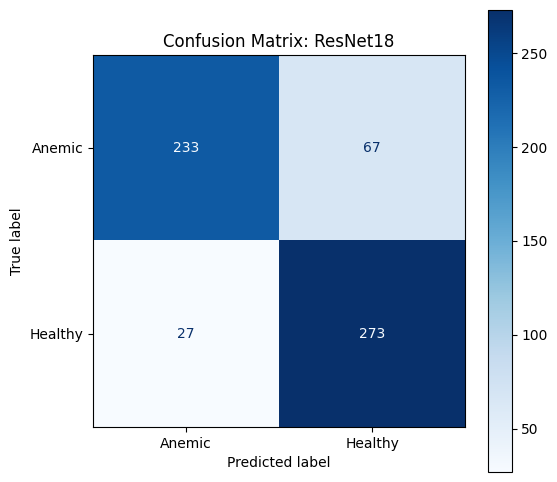

In [ ]:
# Task 3.4: Train and evaluate Pretrained ResNet18

print("Starting Transfer Learning for ResNet18...")

# Train the model (using the same 0.001 learning rate)
history_rn = train_and_validate(
    model_rn,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001
)

# Plot the learning curves
plot_learning_curves(history_rn, "ResNet18 (Transfer Learning)")

# Save the checkpoint to your Google Drive
save_model_and_history(model_rn, history_rn, "Pretrained_ResNet18", save_directory)

# Evaluate on the Test Set immediately
print("\nEvaluating ResNet18 on Test Set...")
evaluate_on_test_set(model_rn, test_loader, class_names, "ResNet18")

# **Task 4: XAI with Integrated Gradients for Custom and Pretrained Models**

In [ ]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.5 MB/s eta 0:00:00


Loading models from Google Drive...
Models loaded successfully!

--- XAI Analysis ---
Target Image True Class: Healthy

Analyzing Best Custom Model (4-Layer CNN)...


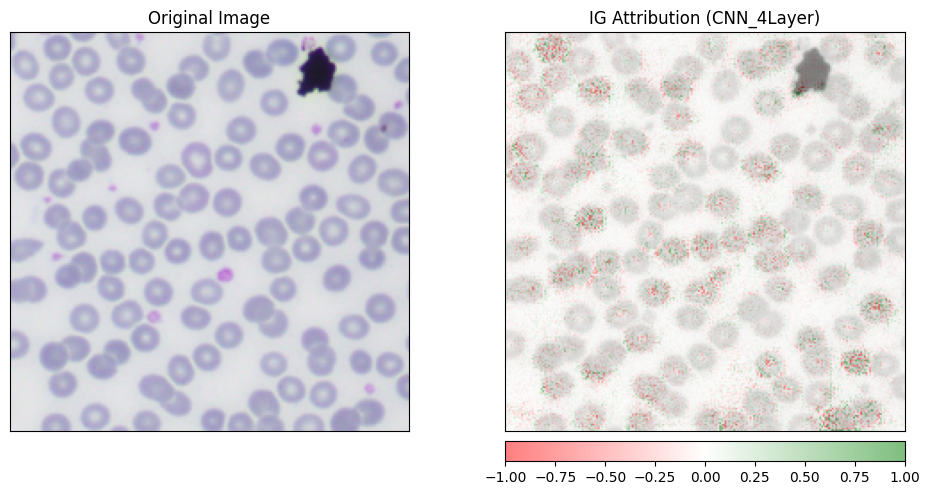

Analyzing Best Pretrained Model (MobileNetV2)...


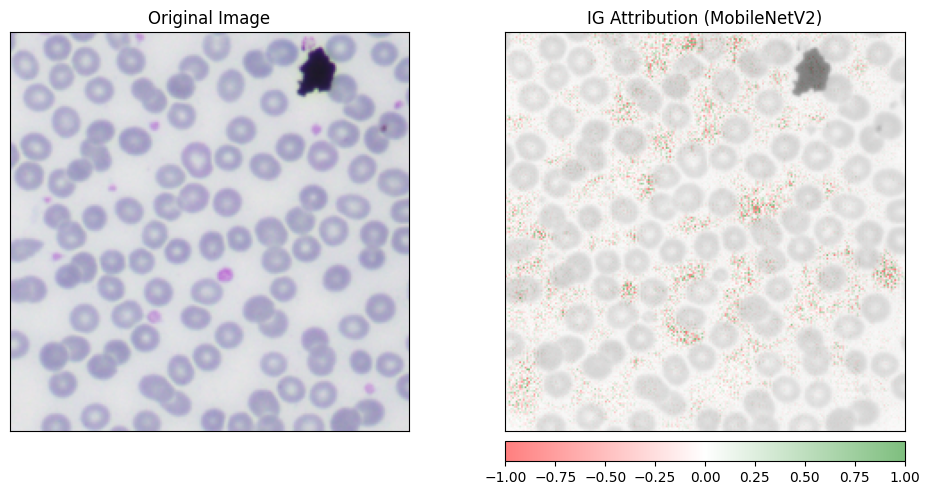

In [ ]:
# Task 4: XAI with Integrated Gradients (including Model Recovery)

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as tv_models  # Aliased to prevent dictionary conflict
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

# --- 1. REDEFINE SETUP FUNCTION SAFELY ---
def setup_pretrained_model_safe(model_name: str, num_classes: int = 2):
    """Safely loads pretrained models avoiding namespace conflicts."""
    if model_name == 'mobilenet':
        model = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        return model

# --- 2. RECOVER THE MODELS FROM DRIVE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading models from Google Drive...")

# Rebuild Skeletons
model_4layer = CNN4Layer(num_classes=2)
model_mn = setup_pretrained_model_safe('mobilenet', num_classes=2)

# Define Drive Paths (Ensure these match your exact save_directory)
save_directory = '/content/drive/MyDrive/ANN_Saved_Models'
path_4layer = os.path.join(save_directory, "CNN_4Layer_weights.pth")
path_mn = os.path.join(save_directory, "Pretrained_MobileNetV2_weights.pth")

# Load Weights
model_4layer.load_state_dict(torch.load(path_4layer, map_location=device))
model_4layer.to(device)
model_4layer.eval()

model_mn.load_state_dict(torch.load(path_mn, map_location=device))
model_mn.to(device)
model_mn.eval()
print("Models loaded successfully!\n")

# --- 3. XAI FUNCTIONS ---
def denormalize_image(tensor):
    """Reverses the ImageNet normalization so the image displays correctly."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def apply_integrated_gradients(model, input_tensor, target_class_idx, class_names, model_name):
    """Generates and plots an Integrated Gradients attribution map."""
    input_tensor = input_tensor.to(device)
    input_tensor.requires_grad = True

    ig = IntegratedGradients(model)

    attributions, delta = ig.attribute(
        inputs=input_tensor,
        target=target_class_idx,
        return_convergence_delta=True
    )

    img_to_show = denormalize_image(input_tensor.squeeze(0).detach())
    attr_to_show = np.transpose(attributions.squeeze(0).cpu().detach().numpy(), (1, 2, 0))

    fig, ax = viz.visualize_image_attr_multiple(
        attr_to_show,
        img_to_show,
        methods=["original_image", "blended_heat_map"],
        signs=["all", "all"],
        show_colorbar=True,
        titles=[f"Original Image", f"IG Attribution ({model_name})"],
        fig_size=(10, 5)
    )
    plt.show()

# --- 4. EXECUTE XAI ON A TEST IMAGE ---
# Fetch a single batch from the test loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Extract the first image and label from the batch
sample_img = images[0].unsqueeze(0)
sample_label = labels[0].item()

print(f"--- XAI Analysis ---")
print(f"Target Image True Class: {class_names[sample_label]}\n")

print(f"Analyzing Best Custom Model (4-Layer CNN)...")
apply_integrated_gradients(model_4layer, sample_img, sample_label, class_names, "CNN_4Layer")

print(f"Analyzing Best Pretrained Model (MobileNetV2)...")
apply_integrated_gradients(model_mn, sample_img, sample_label, class_names, "MobileNetV2")